# 機械学習用データセットの分析

CSV形式のデータセットについて、列構成、基本統計量、欠損、重複、数値分布、カテゴリ分布、相関、外れ値候補を確認します。

このノートブックはデータを読み取って表示するだけで、元のCSVは変更しません。

In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 80)

## 1. 設定

`CSV_PATH` を分析対象のCSVに変更してください。目的変数がある場合は `TARGET_COLUMN` に列名を設定します。

In [11]:
CSV_PATH = Path(r"C:\Users\RD004\Documents\lab\data\HCUDB1\HCUDB1\eval\collected_result(all)_normalized.csv")
READ_CSV_KWARGS = {"encoding": "utf-8-sig"}
TARGET_COLUMN = None  # 例: "target"。目的変数を指定しない場合は None

PLOT_SAMPLE_ROWS = 10_000
MAX_PLOT_COLUMNS = 12
TOP_CATEGORIES = 15
RANDOM_SEED = 42

## 2. CSVの読み込み

In [12]:
if not CSV_PATH.is_file():
    raise FileNotFoundError(f"CSVが見つかりません: {CSV_PATH.resolve()}")

df = pd.read_csv(CSV_PATH, **READ_CSV_KWARGS)
if df.empty:
    raise ValueError("CSVにデータ行がありません。")
if df.columns.duplicated().any():
    duplicated_names = df.columns[df.columns.duplicated()].tolist()
    raise ValueError(f"重複した列名があります: {duplicated_names}")

print(f"読み込み完了: {len(df):,} 行 × {df.shape[1]:,} 列")
display(df.head())

読み込み完了: 4,620 行 × 21 列


,音声ファイル名,話者ID,性別,セリフ,演技感情,テイク,快不快,活性非活性,狂喜・楽しい,驚き,怒り,恐れ,余裕・嬉しい,冷静,嫌い,軽蔑,リラックス・気楽,眠い・疲れた,憂鬱・悲しい,快不快_norm,活性非活性_norm
0,FA-01-01-1.wav,FA,女性,そうなんですか,狂喜・楽しい,1,9.0,27.0,7,8,0,0,12,0,1,1,5,1,0,0.5625,1.6875
1,FA-01-01-2.wav,FA,女性,そうなんですか,狂喜・楽しい,2,11.0,29.0,6,9,0,0,12,2,0,2,4,0,0,0.6875,1.8125
2,FA-01-01-3.wav,FA,女性,そうなんですか,狂喜・楽しい,3,0.0,33.0,7,7,0,2,10,1,1,0,2,0,1,0.0000,2.0625
3,FA-01-02-1.wav,FA,女性,そうなんですか,驚き,1,-4.0,19.0,2,13,2,2,1,1,1,1,3,1,0,-0.2500,1.1875
4,FA-01-02-2.wav,FA,女性,そうなんですか,驚き,2,-6.0,7.0,0,12,0,5,0,3,1,0,1,0,5,-0.3750,0.4375


## 3. データセットと列の概要

In [13]:
print("列名:")
display(pd.DataFrame({"column": df.columns, "dtype": df.dtypes.astype(str).values}))
print(f"メモリ使用量: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MiB")

column_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique": df.nunique(dropna=True),
})
column_summary["unique_pct"] = (column_summary["unique"] / len(df) * 100).round(2)
column_summary["sample"] = [
    df[col].dropna().iloc[0] if df[col].notna().any() else pd.NA
    for col in df.columns
]
display(column_summary)

print("先頭5行:")
display(df.head())
print("末尾5行:")
display(df.tail())
print("全列の基本統計量:")
display(df.describe(include="all").T)

列名:


,column,dtype
0,音声ファイル名,object
1,話者ID,object
2,性別,object
3,セリフ,object
4,演技感情,object
5,テイク,int64
6,快不快,float64
7,活性非活性,float64
8,狂喜・楽しい,int64
9,驚き,int64


メモリ使用量: 2.06 MiB


,dtype,non_null,missing,missing_pct,unique,unique_pct,sample
音声ファイル名,object,4620,0,0.00,4620,100.00,FA-01-01-1.wav
話者ID,object,4620,0,0.00,14,0.30,FA
性別,object,4620,0,0.00,2,0.04,女性
セリフ,object,4620,0,0.00,10,0.22,そうなんですか
演技感情,object,4620,0,0.00,11,0.24,狂喜・楽しい
テイク,int64,4620,0,0.00,3,0.06,1
快不快,float64,4618,2,0.04,65,1.41,9.0
活性非活性,float64,4617,3,0.06,79,1.71,27.0
狂喜・楽しい,int64,4620,0,0.00,15,0.32,7
驚き,int64,4620,0,0.00,17,0.37,8


先頭5行:


,音声ファイル名,話者ID,性別,セリフ,演技感情,テイク,快不快,活性非活性,狂喜・楽しい,驚き,怒り,恐れ,余裕・嬉しい,冷静,嫌い,軽蔑,リラックス・気楽,眠い・疲れた,憂鬱・悲しい,快不快_norm,活性非活性_norm
0,FA-01-01-1.wav,FA,女性,そうなんですか,狂喜・楽しい,1,9.0,27.0,7,8,0,0,12,0,1,1,5,1,0,0.5625,1.6875
1,FA-01-01-2.wav,FA,女性,そうなんですか,狂喜・楽しい,2,11.0,29.0,6,9,0,0,12,2,0,2,4,0,0,0.6875,1.8125
2,FA-01-01-3.wav,FA,女性,そうなんですか,狂喜・楽しい,3,0.0,33.0,7,7,0,2,10,1,1,0,2,0,1,0.0000,2.0625
3,FA-01-02-1.wav,FA,女性,そうなんですか,驚き,1,-4.0,19.0,2,13,2,2,1,1,1,1,3,1,0,-0.2500,1.1875
4,FA-01-02-2.wav,FA,女性,そうなんですか,驚き,2,-6.0,7.0,0,12,0,5,0,3,1,0,1,0,5,-0.3750,0.4375


末尾5行:


,音声ファイル名,話者ID,性別,セリフ,演技感情,テイク,快不快,活性非活性,狂喜・楽しい,驚き,怒り,恐れ,余裕・嬉しい,冷静,嫌い,軽蔑,リラックス・気楽,眠い・疲れた,憂鬱・悲しい,快不快_norm,活性非活性_norm
4615,MN-10-10-2.wav,MN,男性,ごめんなさい,眠い・疲れた,2,-14.0,-15.0,0,0,0,3,0,8,0,0,1,5,7,-0.8750,-0.9375
4616,MN-10-10-3.wav,MN,男性,ごめんなさい,眠い・疲れた,3,-17.0,-8.0,0,0,0,0,1,3,1,0,3,11,4,-1.0625,-0.5000
4617,MN-10-11-1.wav,MN,男性,ごめんなさい,憂鬱・悲しい,1,-11.0,-15.0,0,0,0,6,0,3,0,0,2,0,12,-0.6875,-0.9375
4618,MN-10-11-2.wav,MN,男性,ごめんなさい,憂鬱・悲しい,2,-14.0,-5.0,0,0,0,12,0,1,0,0,0,1,14,-0.8750,-0.3125
4619,MN-10-11-3.wav,MN,男性,ごめんなさい,憂鬱・悲しい,3,-15.0,-5.0,0,1,0,9,2,3,0,0,2,1,9,-0.9375,-0.3125


全列の基本統計量:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
音声ファイル名,4620,4620,FA-01-01-1.wav,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
話者ID,4620,14,FA,330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
性別,4620,2,女性,2640,NaN,NaN,NaN,NaN,NaN,NaN,NaN
セリフ,4620,10,そうなんですか,462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
演技感情,4620,11,狂喜・楽しい,420,NaN,NaN,NaN,NaN,NaN,NaN,NaN
テイク,4620.0,NaN,NaN,NaN,2.0,0.816585,1.0,1.0,2.0,3.0,3.0
快不快,4618.0,NaN,NaN,NaN,-5.062365,12.159114,-34.0,-15.0,-7.0,4.0,30.0
活性非活性,4617.0,NaN,NaN,NaN,1.819147,15.239182,-36.0,-10.0,1.0,13.0,43.0
狂喜・楽しい,4620.0,NaN,NaN,NaN,1.475541,2.530363,0.0,0.0,0.0,2.0,14.0
驚き,4620.0,NaN,NaN,NaN,1.744589,2.728004,0.0,0.0,1.0,2.0,16.0


## 4. 欠損・重複・定数列

欠損値の量と位置、完全に重複した行、値が1種類しかない列を確認します。

完全重複行: 0
定数列: なし
ユニーク値が多い列: ['音声ファイル名']


,missing,missing_pct
活性非活性,3,0.06
活性非活性_norm,3,0.06
快不快,2,0.04
快不快_norm,2,0.04


C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\1804080303.py:24: UserWarning: Glyph 27424 (\N{CJK UNIFIED IDEOGRAPH-6B20}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\1804080303.py:24: UserWarning: Glyph 25613 (\N{CJK UNIFIED IDEOGRAPH-640D}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\1804080303.py:24: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\1804080303.py:24: UserWarning: Glyph 24555 (\N{CJK UNIFIED IDEOGRAPH-5FEB}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\1804080303.py:24: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\1804080303.py:24: UserWarning: Glyph 27963 (\N{CJK UNIFIED IDEOGRAPH-6D3B}) missi

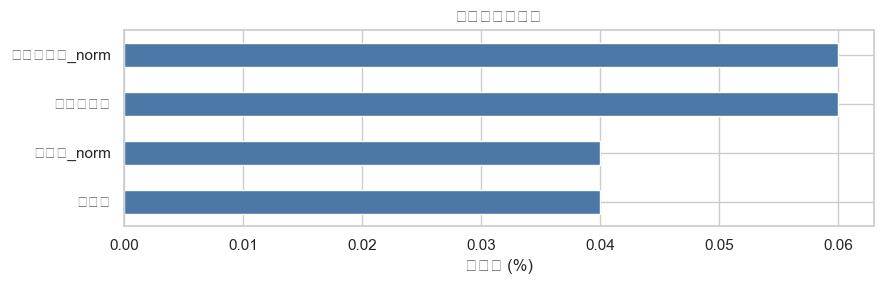

c:\Users\RD004\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 38899 (\N{CJK UNIFIED IDEOGRAPH-97F3}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\RD004\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 22768 (\N{CJK UNIFIED IDEOGRAPH-58F0}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\RD004\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12501 (\N{KATAKANA LETTER HU}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\RD004\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12449 (\N{KATAKANA LETTER SMALL A}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\RD004\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12452 (\N{KATAKANA LETTER I}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\RD004\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users

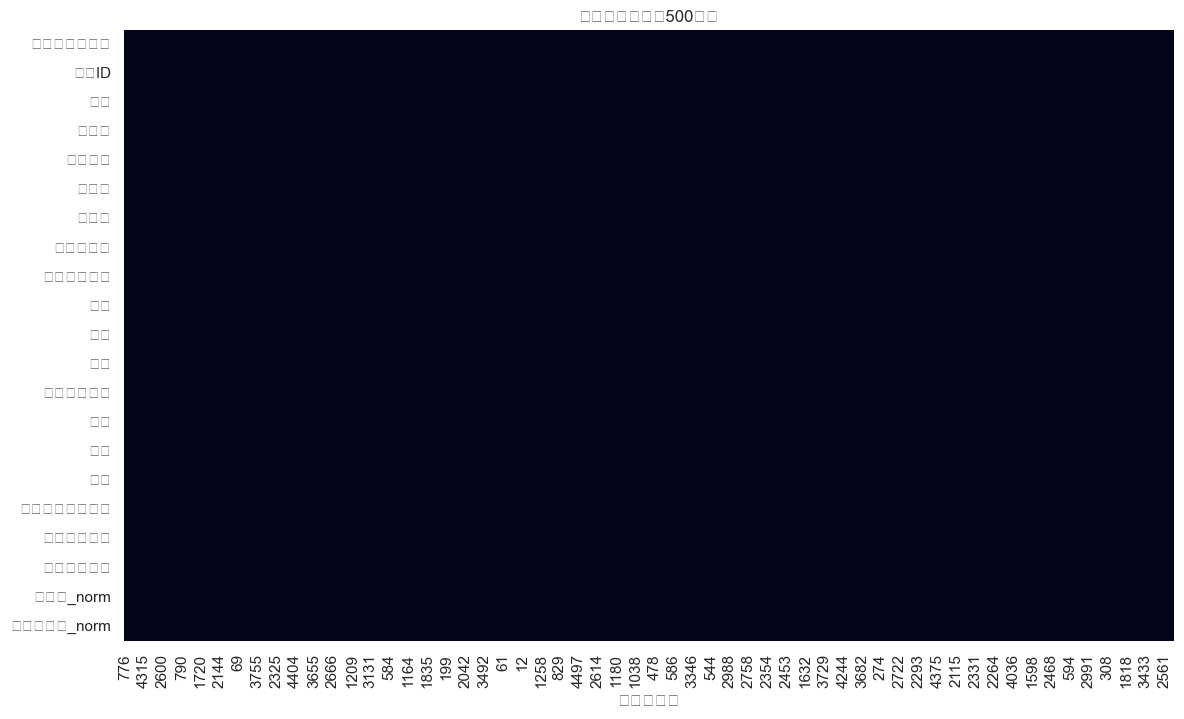

In [14]:
duplicate_rows = int(df.duplicated().sum())
constant_columns = [col for col in df.columns if df[col].nunique(dropna=False) <= 1]
high_cardinality_columns = [
    col for col in df.columns
    if df[col].nunique(dropna=True) >= 20 and df[col].nunique(dropna=True) / len(df) >= 0.9
]

print(f"完全重複行: {duplicate_rows:,}")
print(f"定数列: {constant_columns if constant_columns else 'なし'}")
print(f"ユニーク値が多い列: {high_cardinality_columns if high_cardinality_columns else 'なし'}")

missing_table = column_summary.loc[
    column_summary["missing"] > 0, ["missing", "missing_pct"]
].sort_values("missing_pct", ascending=False)
if missing_table.empty:
    print("欠損値はありません。")
else:
    display(missing_table)
    ax = missing_table["missing_pct"].sort_values().plot.barh(
        figsize=(9, max(3, len(missing_table) * 0.35)), color="#4C78A8"
    )
    ax.set_title("列ごとの欠損率")
    ax.set_xlabel("欠損率 (%)")
    plt.tight_layout()
    plt.show()

    missing_sample = df.sample(min(len(df), 500), random_state=RANDOM_SEED).isna()
    plt.figure(figsize=(12, max(3, min(8, len(df.columns) * 0.35))))
    sns.heatmap(missing_sample.T, cbar=False, yticklabels=True)
    plt.title("欠損位置（最大500行）")
    plt.xlabel("サンプル行")
    plt.tight_layout()
    plt.show()

## 5. 数値列の分析

数値列の統計量、分布、箱ひげ図、相関、四分位範囲による外れ値候補数を確認します。

,count,mean,std,min,25%,50%,75%,max,missing,skew
テイク,4620.0,2.000000,0.816585,1.000,1.0000,2.0000,3.0000,3.0000,0,0.000000
快不快,4618.0,-5.062365,12.159114,-34.000,-15.0000,-7.0000,4.0000,30.0000,2,0.352429
活性非活性,4617.0,1.819147,15.239182,-36.000,-10.0000,1.0000,13.0000,43.0000,3,0.183427
狂喜・楽しい,4620.0,1.475541,2.530363,0.000,0.0000,0.0000,2.0000,14.0000,0,2.206128
驚き,4620.0,1.744589,2.728004,0.000,0.0000,1.0000,2.0000,16.0000,0,2.166718
怒り,4620.0,1.987229,3.185410,0.000,0.0000,0.0000,2.0000,15.0000,0,1.941424
恐れ,4620.0,1.442641,2.022701,0.000,0.0000,1.0000,2.0000,14.0000,0,1.957376
余裕・嬉しい,4620.0,3.142424,3.325402,0.000,1.0000,2.0000,5.0000,15.0000,0,1.223415
冷静,4620.0,4.307576,3.106605,0.000,2.0000,4.0000,6.0000,15.0000,0,0.724801
嫌い,4620.0,2.197403,2.375999,0.000,0.0000,1.0000,3.0000,15.0000,0,1.283360


,q1,q3,iqr,lower_bound,upper_bound,outlier_candidates,outlier_pct
column,,,,,,,
テイク,1.0000,3.0000,2.0000,-2.00000,6.00000,0,0.00
快不快,-15.0000,4.0000,19.0000,-43.50000,32.50000,0,0.00
活性非活性,-10.0000,13.0000,23.0000,-44.50000,47.50000,0,0.00
狂喜・楽しい,0.0000,2.0000,2.0000,-3.00000,5.00000,429,9.29
驚き,0.0000,2.0000,2.0000,-3.00000,5.00000,462,10.00
怒り,0.0000,2.0000,2.0000,-3.00000,5.00000,621,13.44
恐れ,0.0000,2.0000,2.0000,-3.00000,5.00000,274,5.93
余裕・嬉しい,1.0000,5.0000,4.0000,-5.00000,11.00000,117,2.53
冷静,2.0000,6.0000,4.0000,-4.00000,12.00000,47,1.02


C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\420461819.py:40: UserWarning: Glyph 12486 (\N{KATAKANA LETTER TE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\420461819.py:40: UserWarning: Glyph 12452 (\N{KATAKANA LETTER I}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\420461819.py:40: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\420461819.py:40: UserWarning: Glyph 24555 (\N{CJK UNIFIED IDEOGRAPH-5FEB}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\420461819.py:40: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\420461819.py:40: UserWarning: Glyph 27963 (\N{CJK UNIFIED IDEOGRAPH-6D3B}) missing from font(s) Arial.
  plt.ti

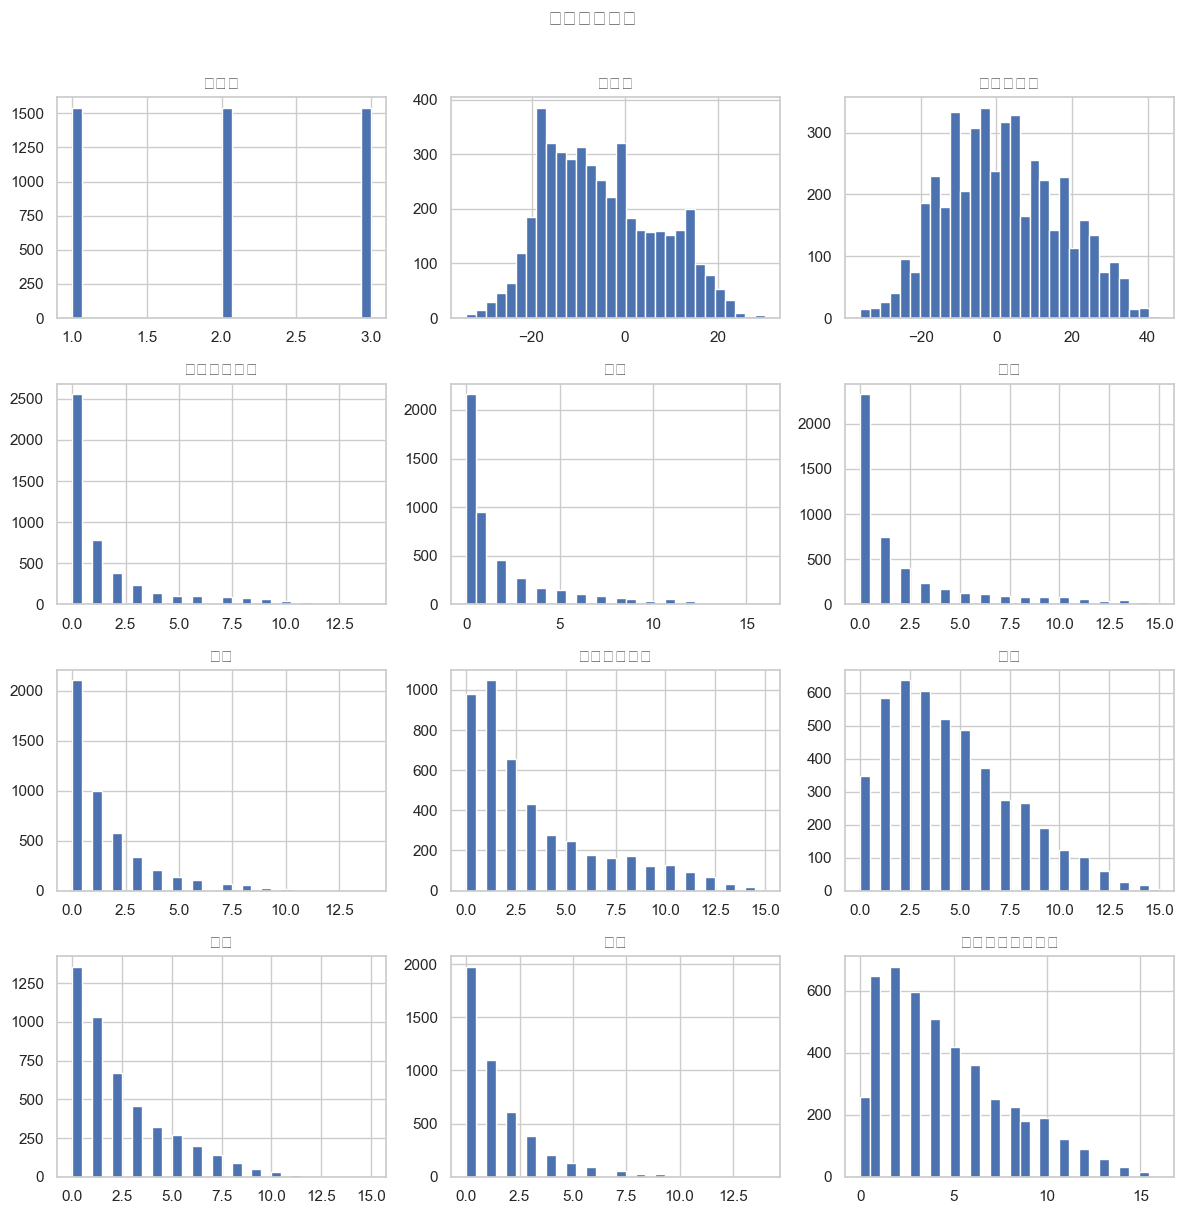

C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\420461819.py:48: UserWarning: Glyph 12486 (\N{KATAKANA LETTER TE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\420461819.py:48: UserWarning: Glyph 12452 (\N{KATAKANA LETTER I}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\420461819.py:48: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\420461819.py:48: UserWarning: Glyph 24555 (\N{CJK UNIFIED IDEOGRAPH-5FEB}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\420461819.py:48: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\420461819.py:48: UserWarning: Glyph 27963 (\N{CJK UNIFIED IDEOGRAPH-6D3B}) missing from font(s) Arial.
  plt.ti

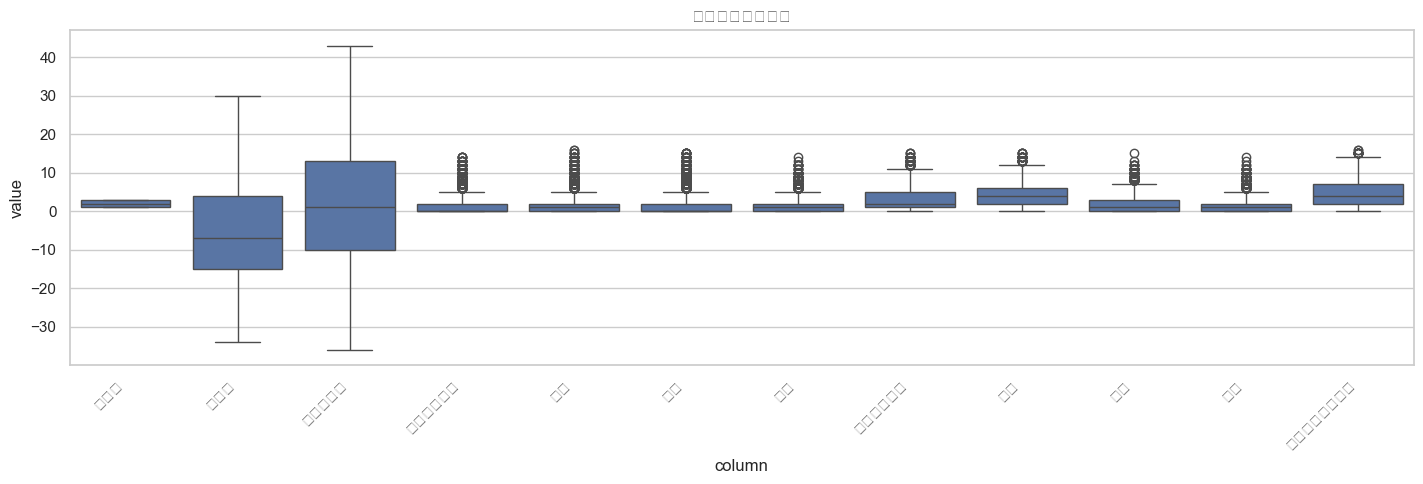

,テイク,快不快,活性非活性,狂喜・楽しい,驚き,怒り,恐れ,余裕・嬉しい,冷静,嫌い,軽蔑,リラックス・気楽
テイク,1.000000,-0.021620,-0.025712,-0.017707,-0.012634,-0.020308,0.003408,-0.008212,-0.033369,0.006695,0.027937,0.028837
快不快,-0.021620,1.000000,0.529687,0.645563,0.055052,-0.516787,-0.300952,0.809686,-0.109400,-0.571769,-0.310044,0.686106
活性非活性,-0.025712,0.529687,1.000000,0.666069,0.364205,0.108065,-0.281886,0.624891,-0.413754,-0.082782,0.027712,0.257622
狂喜・楽しい,-0.017707,0.645563,0.666069,1.000000,0.065711,-0.218047,-0.249927,0.755615,-0.408705,-0.255048,-0.042625,0.245745
驚き,-0.012634,0.055052,0.364205,0.065711,1.000000,-0.027382,0.212039,-0.002313,-0.279295,-0.182406,-0.148114,-0.190862
怒り,-0.020308,-0.516787,0.108065,-0.218047,-0.027382,1.000000,-0.157384,-0.327677,-0.056266,0.646947,0.334288,-0.416931
恐れ,0.003408,-0.300952,-0.281886,-0.249927,0.212039,-0.157384,1.000000,-0.331467,-0.097090,-0.154725,-0.204519,-0.353851
余裕・嬉しい,-0.008212,0.809686,0.624891,0.755615,-0.002313,-0.327677,-0.331467,1.000000,-0.341895,-0.371578,-0.157343,0.534356
冷静,-0.033369,-0.109400,-0.413754,-0.408705,-0.279295,-0.056266,-0.097090,-0.341895,1.000000,-0.025093,-0.061938,0.014354
嫌い,0.006695,-0.571769,-0.082782,-0.255048,-0.182406,0.646947,-0.154725,-0.371578,-0.025093,1.000000,0.534277,-0.429924


c:\Users\RD004\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12486 (\N{KATAKANA LETTER TE}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\RD004\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12452 (\N{KATAKANA LETTER I}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\RD004\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\RD004\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 24555 (\N{CJK UNIFIED IDEOGRAPH-5FEB}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\RD004\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\RD004\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 27963 (\N{CJK UNIFIED IDEOGRAPH-6D3B}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Us

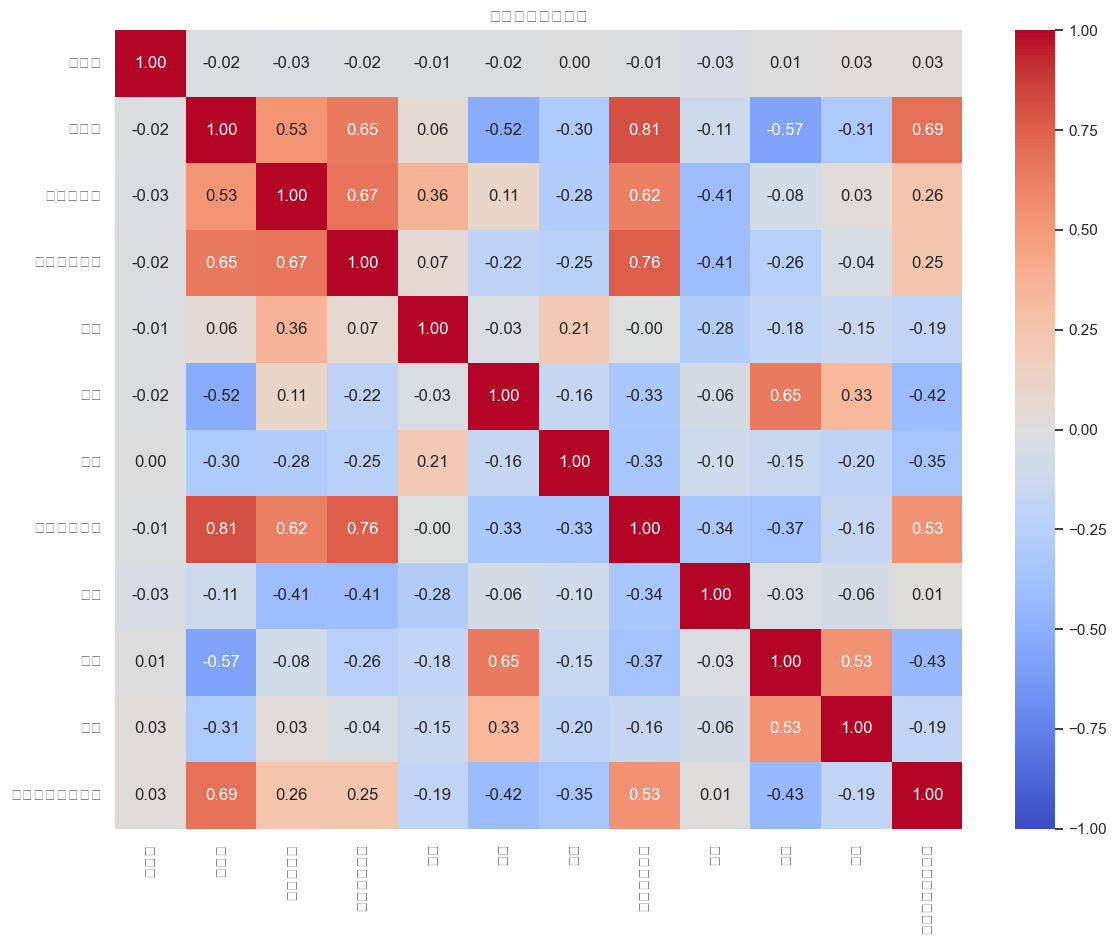

In [15]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
numeric_plot_columns = numeric_columns[:MAX_PLOT_COLUMNS]

if not numeric_columns:
    print("数値列はありません。")
    numeric_summary = pd.DataFrame()
    outlier_summary = pd.DataFrame()
else:
    numeric_summary = df[numeric_columns].describe().T
    numeric_summary["missing"] = df[numeric_columns].isna().sum()
    numeric_summary["skew"] = df[numeric_columns].skew(numeric_only=True)
    display(numeric_summary)

    outlier_rows = []
    for col in numeric_columns:
        series = df[col].dropna()
        q1, q3 = series.quantile([0.25, 0.75]) if not series.empty else (np.nan, np.nan)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        candidates = int(((series < lower) | (series > upper)).sum()) if not series.empty else 0
        outlier_rows.append({
            "column": col, "q1": q1, "q3": q3, "iqr": iqr,
            "lower_bound": lower, "upper_bound": upper,
            "outlier_candidates": candidates,
            "outlier_pct": round(candidates / len(series) * 100, 2) if len(series) else 0.0,
        })
    outlier_summary = pd.DataFrame(outlier_rows).set_index("column")
    display(outlier_summary)

    plottable = [col for col in numeric_plot_columns if df[col].notna().any()]
    if plottable:
        sampled_numeric = df[plottable].sample(
            min(len(df), PLOT_SAMPLE_ROWS), random_state=RANDOM_SEED
        )
        sampled_numeric.hist(
            bins=30, figsize=(12, max(4, 3 * int(np.ceil(len(plottable) / 3))))
        )
        plt.suptitle("数値列の分布", y=1.01)
        plt.tight_layout()
        plt.show()

        long_numeric = sampled_numeric.melt(var_name="column", value_name="value")
        plt.figure(figsize=(max(8, len(plottable) * 1.2), 5))
        sns.boxplot(data=long_numeric, x="column", y="value")
        plt.xticks(rotation=45, ha="right")
        plt.title("数値列の箱ひげ図")
        plt.tight_layout()
        plt.show()

    correlation_columns = [col for col in numeric_plot_columns if df[col].notna().sum() >= 2]
    if len(correlation_columns) >= 2:
        correlation = df[correlation_columns].corr()
        display(correlation)
        plt.figure(figsize=(max(6, len(correlation_columns)), max(5, len(correlation_columns) * 0.8)))
        sns.heatmap(correlation, annot=True, fmt=".2f", vmin=-1, vmax=1, center=0, cmap="coolwarm")
        plt.title("数値列の相関行列")
        plt.tight_layout()
        plt.show()

## 6. カテゴリ列の分析

文字列・カテゴリ・真偽値の列について、値の種類数と上位の値を確認します。

,unique,missing,most_frequent
音声ファイル名,4620,0,FA-01-01-1.wav
話者ID,14,0,FA
性別,2,0,女性
セリフ,10,0,ありがとう（ございます）
演技感情,11,0,リラックス・気楽



[音声ファイル名] 上位15件


,count,percentage
音声ファイル名,,
FA-01-01-1.wav,1,0.02
ME-07-03-3.wav,1,0.02
ME-04-06-1.wav,1,0.02
ME-04-05-3.wav,1,0.02
ME-04-05-2.wav,1,0.02
ME-04-05-1.wav,1,0.02
ME-04-04-3.wav,1,0.02
ME-04-04-2.wav,1,0.02
ME-04-04-1.wav,1,0.02


C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 20214 (\N{CJK UNIFIED IDEOGRAPH-4EF6}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 38899 (\N{CJK UNIFIED IDEOGRAPH-97F3}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 22768 (\N{CJK UNIFIED IDEOGRAPH-58F0}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 12501 (\N{KATAKANA LETTER HU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 12449 (\N{KATAKANA LETTER SMALL A}) missing from font(s) A

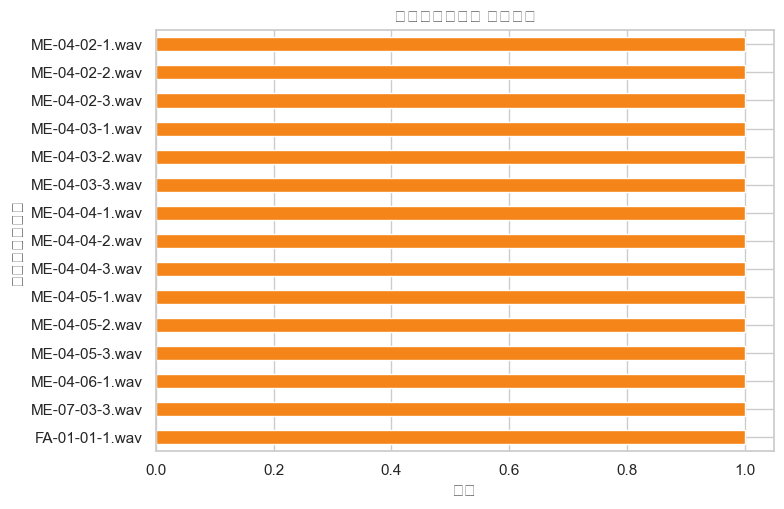


[話者ID] 上位14件


,count,percentage
話者ID,,
FA,330,7.14
FB,330,7.14
FD,330,7.14
FF,330,7.14
FG,330,7.14
FH,330,7.14
FI,330,7.14
FL,330,7.14
MC,330,7.14


C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 20214 (\N{CJK UNIFIED IDEOGRAPH-4EF6}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 35441 (\N{CJK UNIFIED IDEOGRAPH-8A71}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 32773 (\N{CJK UNIFIED IDEOGRAPH-8005}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s

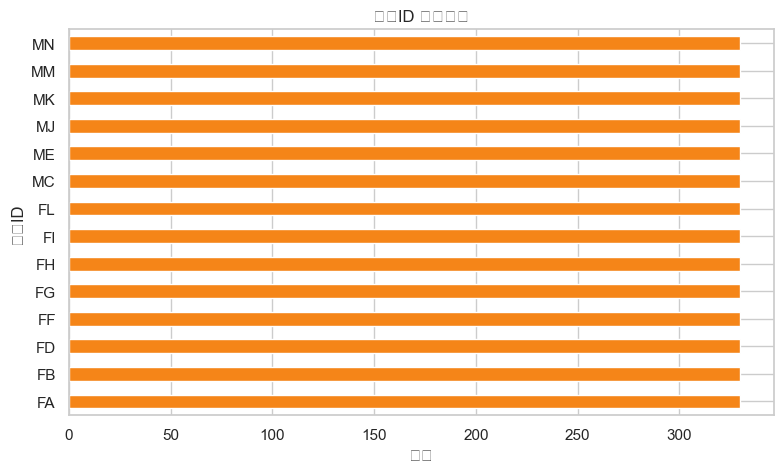


[性別] 上位2件


,count,percentage
性別,,
女性,2640,57.14
男性,1980,42.86


C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 20214 (\N{CJK UNIFIED IDEOGRAPH-4EF6}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 30007 (\N{CJK UNIFIED IDEOGRAPH-7537}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 22899 (\N{CJK UNIFIED IDEOGRAPH-5973}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing fro

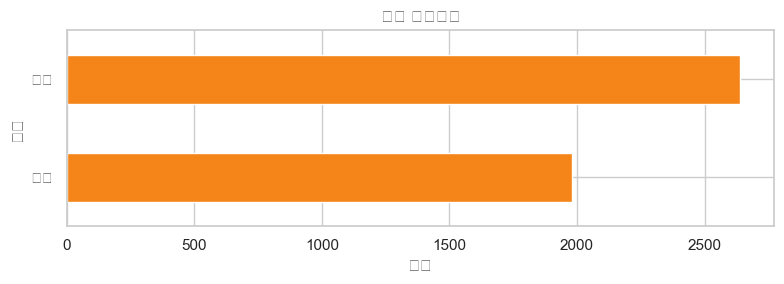


[セリフ] 上位10件


,count,percentage
セリフ,,
そうなんですか,462,10.0
どうなってるの,462,10.0
分かりました,462,10.0
ありがとう（ございます）,462,10.0
覚えていますか,462,10.0
全然嬉しくない,462,10.0
それはできない（よ）,462,10.0
気にしないで,462,10.0
仕方ないな,462,10.0


C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 20214 (\N{CJK UNIFIED IDEOGRAPH-4EF6}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 12381 (\N{HIRAGANA LETTER SO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 12358 (\N{HIRAGANA LETTER U}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 12394 (\N{HIRAGANA LETTER NA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 12435 (\N{HIRAGANA LETTER N}) missing from font(s) Arial.
  plt.tight_layou

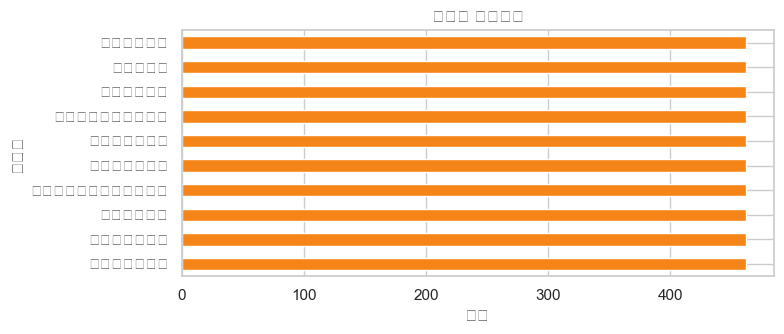


[演技感情] 上位11件


,count,percentage
演技感情,,
狂喜・楽しい,420,9.09
驚き,420,9.09
怒り,420,9.09
恐れ,420,9.09
余裕・嬉しい,420,9.09
冷静,420,9.09
嫌い,420,9.09
軽蔑,420,9.09
リラックス・気楽,420,9.09


C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 20214 (\N{CJK UNIFIED IDEOGRAPH-4EF6}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 29378 (\N{CJK UNIFIED IDEOGRAPH-72C2}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 21916 (\N{CJK UNIFIED IDEOGRAPH-559C}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 12539 (\N{KATAKANA MIDDLE DOT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\RD004\AppData\Local\Temp\ipykernel_7716\281393588.py:27: UserWarning: Glyph 27005 (\N{CJK UNIFIED IDEOGRAPH-697D}) missing from font(

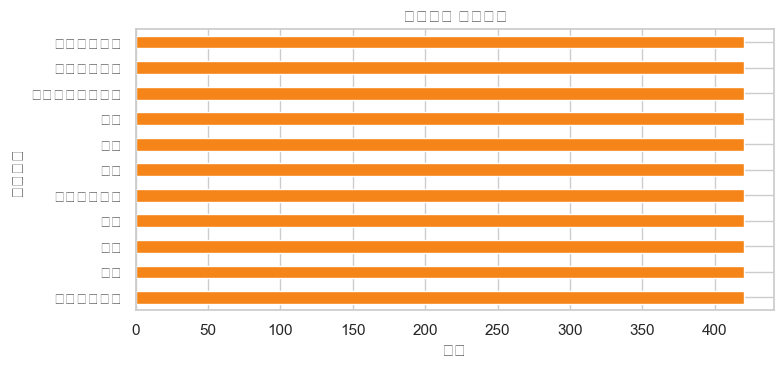

In [16]:
categorical_columns = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

if not categorical_columns:
    print("カテゴリ列はありません。")
else:
    categorical_summary = pd.DataFrame({
        "unique": df[categorical_columns].nunique(dropna=True),
        "missing": df[categorical_columns].isna().sum(),
        "most_frequent": [
            df[col].mode(dropna=True).iloc[0] if not df[col].mode(dropna=True).empty else pd.NA
            for col in categorical_columns
        ],
    })
    display(categorical_summary)

    for col in categorical_columns[:MAX_PLOT_COLUMNS]:
        counts = df[col].fillna("<MISSING>").value_counts().head(TOP_CATEGORIES)
        table = pd.DataFrame({
            "count": counts,
            "percentage": (counts / len(df) * 100).round(2),
        })
        print(f"\n[{col}] 上位{min(TOP_CATEGORIES, len(counts))}件")
        display(table)
        counts.sort_values().plot.barh(figsize=(8, max(3, len(counts) * 0.35)), color="#F58518")
        plt.title(f"{col} の値分布")
        plt.xlabel("件数")
        plt.tight_layout()
        plt.show()

## 7. 目的変数の分析（任意）

`TARGET_COLUMN` を設定した場合、目的変数の型に応じて分布と数値特徴量との関係を表示します。

In [17]:
if TARGET_COLUMN is None:
    print("TARGET_COLUMN は未設定です。")
elif TARGET_COLUMN not in df.columns:
    raise KeyError(f"目的変数 {TARGET_COLUMN!r} がCSVにありません。")
else:
    target = df[TARGET_COLUMN]
    print(f"目的変数: {TARGET_COLUMN}")
    print(f"データ型: {target.dtype}")
    print(f"欠損数: {target.isna().sum():,}")
    print(f"ユニーク数: {target.nunique(dropna=True):,}")

    if pd.api.types.is_numeric_dtype(target):
        display(target.describe().to_frame("value"))
        target.dropna().hist(bins=30, figsize=(8, 4), color="#54A24B")
        plt.title(f"目的変数 {TARGET_COLUMN} の分布")
        plt.xlabel(TARGET_COLUMN)
        plt.tight_layout()
        plt.show()

        feature_columns = [col for col in numeric_columns if col != TARGET_COLUMN]
        if feature_columns:
            target_correlations = df[feature_columns + [TARGET_COLUMN]].corr()[TARGET_COLUMN]
            target_correlations = target_correlations.drop(TARGET_COLUMN).sort_values(key=abs, ascending=False)
            display(target_correlations.to_frame("correlation_with_target"))
    else:
        target_counts = target.fillna("<MISSING>").value_counts()
        target_table = pd.DataFrame({
            "count": target_counts,
            "percentage": (target_counts / len(df) * 100).round(2),
        })
        display(target_table)
        target_counts.head(TOP_CATEGORIES).sort_values().plot.barh(figsize=(8, 4), color="#54A24B")
        plt.title(f"目的変数 {TARGET_COLUMN} の分布")
        plt.xlabel("件数")
        plt.tight_layout()
        plt.show()

        feature_columns = [col for col in numeric_columns if col != TARGET_COLUMN][:MAX_PLOT_COLUMNS]
        if feature_columns and target.nunique(dropna=True) <= TOP_CATEGORIES:
            display(df.groupby(TARGET_COLUMN, dropna=False)[feature_columns].mean())

TARGET_COLUMN は未設定です。


## 8. 分析結果の要約

In [18]:
summary = {
    "rows": len(df),
    "columns": df.shape[1],
    "numeric_columns": len(numeric_columns),
    "categorical_columns": len(categorical_columns),
    "columns_with_missing": int((df.isna().sum() > 0).sum()),
    "total_missing_values": int(df.isna().sum().sum()),
    "duplicate_rows": duplicate_rows,
    "constant_columns": len(constant_columns),
    "high_cardinality_columns": len(high_cardinality_columns),
    "outlier_candidates": int(outlier_summary["outlier_candidates"].sum()) if not outlier_summary.empty else 0,
}
display(pd.Series(summary, name="value").to_frame())

if constant_columns:
    print("定数列:", constant_columns)
if high_cardinality_columns:
    print("ユニーク値が多い列:", high_cardinality_columns)
if not outlier_summary.empty:
    detected = outlier_summary[outlier_summary["outlier_candidates"] > 0]
    if not detected.empty:
        print("外れ値候補が検出された数値列:")
        display(detected[["outlier_candidates", "outlier_pct"]])

,value
rows,4620
columns,21
numeric_columns,16
categorical_columns,5
columns_with_missing,4
total_missing_values,10
duplicate_rows,0
constant_columns,0
high_cardinality_columns,1
outlier_candidates,2745


ユニーク値が多い列: ['音声ファイル名']
外れ値候補が検出された数値列:


,outlier_candidates,outlier_pct
column,,
狂喜・楽しい,429,9.29
驚き,462,10.00
怒り,621,13.44
恐れ,274,5.93
余裕・嬉しい,117,2.53
冷静,47,1.02
嫌い,182,3.94
軽蔑,211,4.57
リラックス・気楽,18,0.39
